In [86]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [87]:
from sklearn.datasets import make_classification
X,y= make_classification(n_samples=1000,n_features=3,n_redundant=1,n_classes=2,random_state=42)

In [88]:
X

array([[ 2.48547786,  2.39963589, -1.46526917],
       [ 2.20403962, -1.06965652,  0.00979545],
       [-0.5726534 , -0.75494788,  0.42032991],
       ...,
       [-0.41608875,  0.46668963, -0.11024494],
       [-1.57936997,  2.48498245, -0.71060102],
       [-0.43277356,  0.89093028, -0.28069604]], shape=(1000, 3))

In [89]:
y

array([1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1,

In [90]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)


In [91]:
from sklearn.neighbors import KNeighborsClassifier

In [92]:
classifier=KNeighborsClassifier(n_neighbors=5,algorithm='auto')
classifier.fit(X_train,y_train)

KNeighborsClassifier()

In [93]:
y_pred=classifier.predict(X_test)

In [94]:
from sklearn.metrics import accuracy_score,classification_report,ConfusionMatrixDisplay,confusion_matrix

ACCURACY: 91.81818181818183 %
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       165
           1       0.94      0.89      0.92       165

    accuracy                           0.92       330
   macro avg       0.92      0.92      0.92       330
weighted avg       0.92      0.92      0.92       330



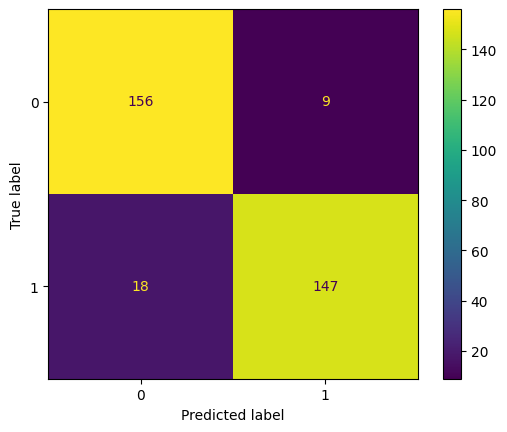

In [95]:
print("ACCURACY:",accuracy_score(y_test,y_pred)*100,"%")
print(classification_report(y_test,y_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,y_pred))
disp.plot()

### HYPERPARAMETER TUNING

In [96]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

In [97]:
cv=StratifiedKFold()

In [98]:
params={'n_neighbors':list(range(1,11)),
        'weights': ['uniform', 'distance'],
        'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
        'p':[1,2]
}

In [99]:
grid=GridSearchCV(KNeighborsClassifier(),param_grid=params,refit=True,verbose=3,cv=cv,n_jobs=-1)

In [100]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 160 candidates, totalling 800 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'p': [1, 2], 'weights': ['uniform', 'distance']},
             verbose=3)

In [101]:
grid.best_params_

{'algorithm': 'auto', 'n_neighbors': 7, 'p': 2, 'weights': 'uniform'}

In [102]:
y_pred1=grid.predict(X_test)

ACCURACY: 92.12121212121212 %
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       165
           1       0.94      0.90      0.92       165

    accuracy                           0.92       330
   macro avg       0.92      0.92      0.92       330
weighted avg       0.92      0.92      0.92       330



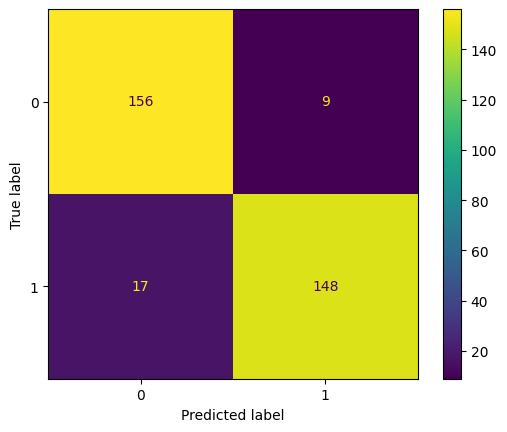

In [103]:
print("ACCURACY:",accuracy_score(y_test,y_pred1)*100,"%")
print(classification_report(y_test,y_pred1))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,y_pred1))
disp.plot()